In [1]:
import sys
import time
import random
import numpy as np
import pandas as pd
from functools import partial
import matplotlib.pyplot as plt
import pennylane as qp

### Number of Gates (specifying the number of index bits instead of QROM_size)
num_index_bits = int(np.ceil(np.log2(QROM_size)))

- [ ]  BIGGER QUESTION: Should we make the input the number of index bits or QROM size? If we eliminate QROM_size, then a non-factor of 2 doesn’t matter to us.
- [ ]  We can make an assumption that the data inputs are a factor of 2, because currently we’re working with 32x32 images or even up to 256x256 images for processing.

Assumption is that the estimation only works for size >= 2 because less than that doesn't need any index bits and we just write memory directly

In [71]:
def draw_qrom(num_index_bits, num_swap_bits=0, bits_per_value=2, worstcase=False, detail=2):
    
    def generate_bitstrings(array_length, bit_length):
        return [f"{random.randint(0, 2**bit_length - 1):0{bit_length}b}" for _ in range(array_length)]

    def worst(array_length, bit_length):
        return [f"{2**bit_length - 1:0{bit_length}b}" for _ in range(array_length)]
    
    bitstrings = generate_bitstrings(2**num_index_bits, bits_per_value)
    if worst: bitstrings = worst(2**num_index_bits, bits_per_value)
    
    control_wires = np.arange(num_index_bits)
    target_wires  = np.arange(num_index_bits, num_index_bits + bits_per_value)
    work_wires    = np.arange(target_wires[-1] + 1, target_wires[-1] + 1 + bits_per_value*(2**num_swap_bits - 1))
    
    # Line added for drawing purposes only
    @partial(qp.transforms.decompose, max_expansion=detail)
    @qp.set_shots(1)
    @qp.qnode(qp.device("default.qubit"))
    def circuit(index):
        qp.BasisState(index, wires=control_wires)
        qp.QROM(bitstrings, control_wires, target_wires, work_wires, clean=False)
        return qp.sample(wires=target_wires), qp.sample(wires=target_wires)
    
    qp.draw_mpl(circuit, style="pennylane")(0)
    plt.show()

In [47]:
def analyze_qrom(num_index_bits, num_swap_bits=0, bits_per_value=2, print_out=True, worstcase=False):
    
    def generate_bitstrings(array_length, bit_length):
        return [f"{random.randint(0, 2**bit_length - 1):0{bit_length}b}" for _ in range(array_length)]
    
    def worst(array_length, bit_length):
        return [f"{2**bit_length - 1:0{bit_length}b}" for _ in range(array_length)]
    
    bitstrings = generate_bitstrings(2**num_index_bits, bits_per_value)
    if worst: bitstrings = worst(2**num_index_bits, bits_per_value)
    
    control_wires = np.arange(num_index_bits)
    target_wires  = np.arange(num_index_bits, num_index_bits + bits_per_value)
    work_wires    = np.arange(target_wires[-1] + 1, target_wires[-1] + 1 + bits_per_value*(2**num_swap_bits - 1))
    
    @partial(qp.compile, basis_set="CNOT")  # Line added for resource estimation purposes only.
    @qp.set_shots(1)
    @qp.qnode(qp.device("default.qubit"))
    def circuit(index):
        qp.BasisState(index, wires=control_wires)
        qp.QROM(bitstrings, control_wires, target_wires, work_wires, clean=False)
        return qp.sample(wires=target_wires), qp.sample(wires=target_wires)
    
    r = qp.specs(circuit)(0)["resources"]

    num_qubits = len(control_wires) + len(target_wires) + len(work_wires)
    oneQ = r.gate_sizes.get(1,0)
    twoQ = r.gate_sizes.get(2,0)

    if print_out:
        print("Number of qubits: ", num_qubits)
        print("One-qubit gates: ", oneQ)
        print("Two-qubit gates: ", twoQ)
        print(f"Depth: {r.depth}")

    return num_qubits, oneQ, twoQ, r.depth

In [4]:
def run_analyze_qrom(num_index_bits, num_swap_bits=0, bits_per_value=2, print_out=True, N=30):
    qubits_list = []
    oneQ_list = []
    twoQ_list = []
    depth_list = []
    
    for _ in range(N):
        num_qubits, oneQ, twoQ, depth = analyze_qrom(num_index_bits, num_swap_bits, bits_per_value, print_out=False)
        qubits_list.append(num_qubits)
        oneQ_list.append(oneQ)
        twoQ_list.append(twoQ)
        depth_list.append(depth)
    
    for name, data in {
        "Qubits": qubits_list,
        "1Q Gates": oneQ_list,
        "2Q Gates": twoQ_list,
        "Depth": depth_list,
    }.items():
        print(
            f"{name:10s} | "
            f"min={np.min(data):.2f} | "
            f"max={np.max(data):.2f} | "
            f"mean={np.mean(data):.2f}"
        )

In [5]:
def gates_MultiControlledX(k):

    if k == 0: return 0, 0, 0
    wires = list(range(k + 1))  # k controls + 1 target

    @partial(qp.compile, basis_set="CNOT")
    @qp.qnode(qp.device("default.qubit"))
    def circuit():
        qp.MultiControlledX(wires=wires)
        return qp.state()

    r = qp.specs(circuit)()["resources"]
    return r.gate_sizes.get(1, 0), r.gate_sizes.get(2, 0), r.depth

In [98]:
def estimate_gates(num_index_bits, num_swap_bits=0, bits_per_value=2):

    num_select_bits = num_index_bits - num_swap_bits

    oneQ_mcx, twoQ_mcx, _ = gates_MultiControlledX(num_select_bits)
    oneQ_ccx, twoQ_ccx, _ = gates_MultiControlledX(2)
    
    oneQ_select_lines = oneQ_mcx * bits_per_value * 2**num_select_bits
    oneQ_idx_switching = 2**(num_index_bits) - 1 # sum(2**x for x in range(num_idx_its + 1))
    oneQ_swap_lines = oneQ_ccx * bits_per_value * (2**num_swap_bits - 1)
    
    oneQ = oneQ_select_lines + oneQ_idx_switching + oneQ_swap_lines

    # Deal with teh num_select bits.
    twoQ_select_lines = twoQ_mcx * bits_per_value * 2**num_index_bits
    twoQ_swap_lines = (twoQ_ccx + 2) * bits_per_value * (2**num_swap_bits - 1) # Add 2 for the 2 CNOTs for the CSWAP
    twoQ = twoQ_select_lines + twoQ_swap_lines
    
    # print(f"{twoQ_mcx, bits_per_value, num_select_bits}")
    print(f"Estimated 1Q Gates: {oneQ}")
    print(f"Estimated 2Q Gates: {twoQ}")


## Testing at Number of Index Bits = 6
Unsuccessful. Predicted the 2Q gates very exact except for 0 swap bits, but the 1Q gate predictions are wild. Still have no idea where depth goes.

In [83]:
bits_per_value = 2
num_index_bits = 6

swap_bits_list = []
qubits_list = []
oneQ_list = []
twoQ_list = []
depth_list = []

for num_swap_bits in range(num_index_bits + 1):

    start = time.perf_counter()
    
    num_qubits, oneQ, twoQ, depth = analyze_qrom(num_index_bits, num_swap_bits, bits_per_value, print_out=False, worstcase=True)
    swap_bits_list.append(num_swap_bits)
    qubits_list.append(num_qubits)
    oneQ_list.append(oneQ)
    twoQ_list.append(twoQ)
    depth_list.append(depth)

    elapsed = time.perf_counter() - start
    print(f"Done: {num_swap_bits} swap bits in {elapsed:.6f} s")

Done: 0 swap bits in 172.246407 s
Done: 1 swap bits in 135.604446 s
Done: 2 swap bits in 29.520310 s
Done: 3 swap bits in 5.441041 s
Done: 4 swap bits in 1.383245 s
Done: 5 swap bits in 0.598411 s
Done: 6 swap bits in 2.684165 s


In [92]:
gate_fidelity = 0.999

df = pd.DataFrame({
    "Number of Swap Bits": swap_bits_list,
    "Qubits": qubits_list,
    "1-Qubit Gates": oneQ_list,
    "2-Qubit Gates": twoQ_list,
    "Depth": depth_list,
    f"Fidelity (Gate Fidelity: {gate_fidelity})":
        gate_fidelity ** np.array(depth_list)
})

pd.options.display.float_format = "{:.3f}".format

df

,Number of Swap Bits,Qubits,1-Qubit Gates,2-Qubit Gates,Depth,Fidelity (Gate Fidelity: 0.999)
0,0,8,103105,48640,102064,0.000
1,1,10,47659,22544,47239,0.000
2,2,14,20113,9776,20871,0.000
3,3,22,6233,3184,5647,0.004
4,4,38,1949,1008,1410,0.244
5,5,70,808,624,423,0.655
6,6,134,1766,1008,596,0.551


Having less 1Q gates than 2Q gates is very suspicious, so that's a red flag. At least we can use the 2Q gate count as an initial first best guess.

In [100]:
for num_swap_bits in range(num_index_bits + 1):
    print(f"Swap Bits: {num_swap_bits}")
    estimate_gates(6, num_swap_bits, 2)
    print("")

Swap Bits: 0
Estimated 1Q Gates: 89919
Estimated 2Q Gates: 41472

Swap Bits: 1
Estimated 1Q Gates: 24345
Estimated 2Q Gates: 22544

Swap Bits: 2
Estimated 1Q Gates: 5197
Estimated 2Q Gates: 9776

Swap Bits: 3
Estimated 1Q Gates: 1029
Estimated 2Q Gates: 3184

Swap Bits: 4
Estimated 1Q Gates: 557
Estimated 2Q Gates: 1008

Swap Bits: 5
Estimated 1Q Gates: 869
Estimated 2Q Gates: 624

Swap Bits: 6
Estimated 1Q Gates: 1701
Estimated 2Q Gates: 1008



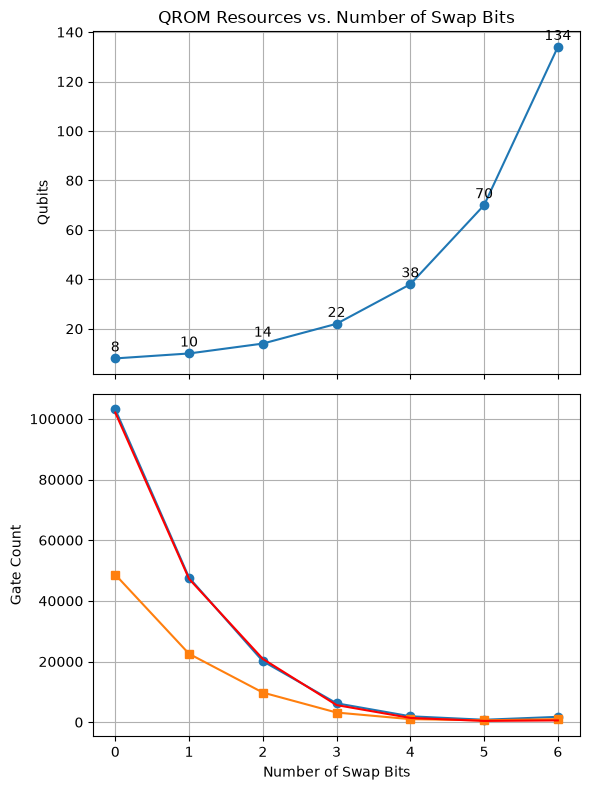

In [91]:
fig, ax = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

# Qubits
ax[0].plot(swap_bits_list, qubits_list, "o-")
for x, y in zip(swap_bits_list, qubits_list):
    ax[0].annotate(f"{y}", (x, y), xytext=(0, 5),
                   textcoords="offset points", ha="center")

ax[0].set_ylabel("Qubits")
ax[0].set_title("QROM Resources vs. Number of Swap Bits")
ax[0].grid()

# Gates
ax[1].plot(swap_bits_list, oneQ_list, "o-", label="1Q Gates")
ax[1].plot(swap_bits_list, twoQ_list, "s-", label="2Q Gates")
ax[1].plot(swap_bits_list, depth_list, "r-", label="Depth")

ax[1].set_xlabel("Number of Swap Bits")
ax[1].set_ylabel("Gate Count")
ax[1].grid()

# Combined legend
lines1, labels1 = ax[1].get_legend_handles_labels()
# lines2, labels2 = ax[2].get_legend_handles_labels()
# ax[1].legend(lines1 + lines2, labels1 + labels2)

plt.tight_layout()
plt.show()

## Initial Optimization Algorithm

Let's first experiment with making a QROM for storing 8x8 iamge of uint8, so 6 index bits and 8 bits per value. I want to make a reinforcement learning algorithm that optimizes by minimizing the depth of the circuit. Since we chave a prediction of what the number of 2Q gates are, we can use our estimated number of 2Q gates, run that estimation for all the possible number of swap bits, and select the combination with the smallest estimation of 2Q gates as our initial guess. That way we can start with a circuit that doesn't take an entire millenia to run. Then, we can find the actual number of gates and depth with oneQ = r.gate_sizes.get(1,0) twoQ = r.gate_sizes.get(2,0) and r.depth to optimize for the combination with the smallest actual depth.

I do want to jump into RL for these couple reasons. First, build an initial framework to build off of for later. Second, have a natural behavior of... say we have an initial guess with a measured depth. We will then either increase or decrease the number of SWAP bits. If that change increases the depth, then have the RL algorithm automatically check the opposite direction in which we increased/decreased the number of SWAP bits. If that change decreased the depth, keep iterating in that same direction. The shape of the relationship between number of swap bits and depth appears to be largely parabolic, so this methodology might work.